# Unit 5 code companion: When a Line Is Not Enough

Read a residual plot, fix a fan with a log, grow a decision tree, and use what the tree found to improve the regression. Short cells, meant to be run one at a time.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

## Setup



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.model_selection import train_test_split

gems = pd.read_csv("https://drbob-richardson.github.io/stat220/F2026/data/diamonds.csv")
gems.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,1.10,Ideal,H,SI2,62.0,55.0,4733,6.61,6.65,4.11
1,1.29,Ideal,H,SI1,62.6,56.0,6424,6.96,6.93,4.35
2,1.20,Premium,I,SI1,61.1,58.0,5510,6.88,6.80,4.18
3,1.50,Ideal,F,SI1,60.9,56.0,8770,7.43,7.36,4.50
4,0.90,Very Good,F,VS2,61.7,57.0,4493,6.17,6.21,3.82


## 1. The obvious model



In [2]:
fit = smf.ols("price ~ carat + C(cut) + C(color) + C(clarity)", data=gems).fit()
print("R-squared:", round(fit.rsquared, 3))

R-squared: 0.916


## 2. Look at the residuals first



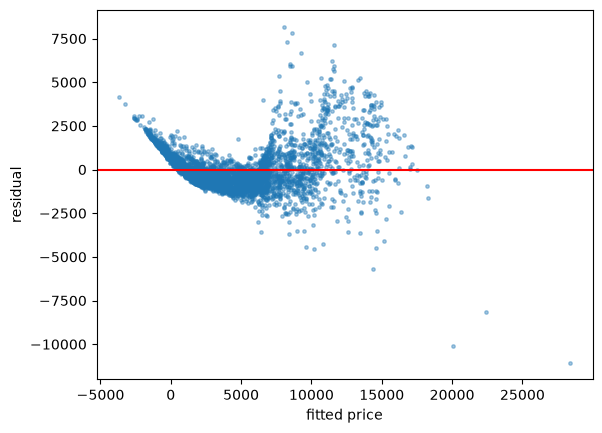

In [3]:
plt.scatter(fit.fittedvalues, fit.resid, s=6, alpha=0.4)
plt.axhline(0, color="red")
plt.xlabel("fitted price"); plt.ylabel("residual");

The spread widens from left to right, and the middle of the cloud bends. A straight line can do nothing about either one.

## 3. Put a number on the fan



In [4]:
resid = pd.DataFrame({"fitted": fit.fittedvalues, "resid": fit.resid})
low = resid[resid.fitted < resid.fitted.median()].resid.std()
high = resid[resid.fitted >= resid.fitted.median()].resid.std()
print("fan ratio:", round(high / low, 2))

fan ratio: 1.98


Near 1 means even spread. This is 2: the errors on expensive stones are twice the size of the errors on cheap ones.

## 4. Take logs of both



In [5]:
logfit = smf.ols("np.log(price) ~ np.log(carat) + C(cut) + C(color) + C(clarity)",
                 data=gems).fit()
print("R-squared:", round(logfit.rsquared, 3))

R-squared: 0.983


## 5. The same picture, after the fix



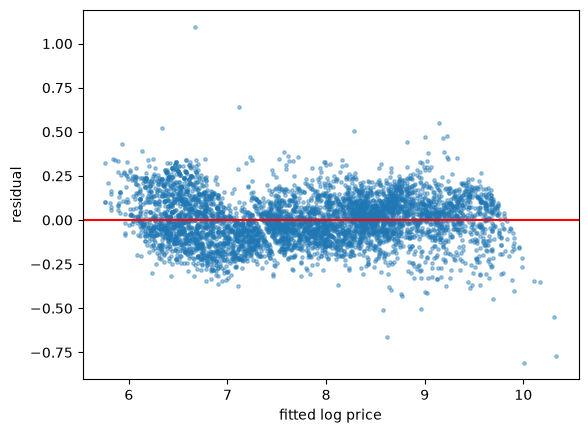

In [6]:
plt.scatter(logfit.fittedvalues, logfit.resid, s=6, alpha=0.4)
plt.axhline(0, color="red")
plt.xlabel("fitted log price"); plt.ylabel("residual");

## 6. Read the coefficient



In [7]:
b = logfit.params["np.log(carat)"]
print("elasticity:", round(b, 2))
print("a stone 10% heavier costs about", round(100 * (1.10**b - 1), 1), "% more")

elasticity: 1.88
a stone 10% heavier costs about 19.6 % more


Both sides logged, so the coefficient is a percentage for a percentage.

## 7. One split, chosen by hand

A tree picks the cut that leaves the two groups as alike inside as possible. You can do the same arithmetic yourself.

In [8]:
def sse(cut):
    left = gems.price[gems.carat <= cut]
    right = gems.price[gems.carat > cut]
    return ((left - left.mean())**2).sum() + ((right - right.mean())**2).sum()

for cut in [0.5, 0.8, 1.0, 1.2, 1.5]:
    print(cut, format(sse(cut), ".3g"))

0.5 5.26e+10
0.8 3.39e+10
1.0 3.14e+10
1.2 3.27e+10
1.5 3.83e+10


## 8. The same split, from sklearn



In [9]:
X = pd.get_dummies(gems[["carat", "cut", "color", "clarity"]], drop_first=True)
stump = DecisionTreeRegressor(max_depth=1, random_state=0).fit(X, gems.price)
print(export_text(stump, feature_names=list(X.columns), decimals=2))

|--- carat <= 1.00
|   |--- value: [1616.86]
|--- carat >  1.00
|   |--- value: [8121.15]



## 9. Keep splitting



In [10]:
tree = DecisionTreeRegressor(max_depth=3, random_state=0).fit(X, gems.price)
print(export_text(tree, feature_names=list(X.columns), decimals=2))

|--- carat <= 1.00
|   |--- carat <= 0.61
|   |   |--- carat <= 0.47
|   |   |   |--- value: [781.31]
|   |   |--- carat >  0.47
|   |   |   |--- value: [1655.05]
|   |--- carat >  0.61
|   |   |--- carat <= 0.81
|   |   |   |--- value: [2634.94]
|   |   |--- carat >  0.81
|   |   |   |--- value: [3810.63]
|--- carat >  1.00
|   |--- carat <= 1.38
|   |   |--- clarity_SI2 <= 0.50
|   |   |   |--- value: [6683.63]
|   |   |--- clarity_SI2 >  0.50
|   |   |   |--- value: [4573.79]
|   |--- carat >  1.38
|   |   |--- carat <= 1.73
|   |   |   |--- value: [10717.93]
|   |   |--- carat >  1.73
|   |   |   |--- value: [14604.90]



The first cut is at **1.00 carat**. Weight is continuous, so there is no reason for the best cut to land on a round number.

## 10. How deep to go



In [11]:
Xtr, Xte, ytr, yte = train_test_split(X, gems.price, test_size=0.3, random_state=0)

for depth in [1, 3, 5, 8, 12, 20]:
    t = DecisionTreeRegressor(max_depth=depth, random_state=0).fit(Xtr, ytr)
    fitted = np.sqrt(((ytr - t.predict(Xtr))**2).mean())
    heldout = np.sqrt(((yte - t.predict(Xte))**2).mean())
    print(f"depth {depth:>2}   on its own rows {fitted:7.0f}   on held-back rows {heldout:7.0f}")

depth  1   on its own rows    2480   on held-back rows    2442
depth  3   on its own rows    1417   on held-back rows    1392
depth  5   on its own rows    1212   on held-back rows    1180
depth  8   on its own rows     900   on held-back rows    1061
depth 12   on its own rows     448   on held-back rows    1077
depth 20   on its own rows     166   on held-back rows    1098


The first column keeps falling. The second one bottoms out and then drifts back up. Only the second one can pick a depth.

## 11. Why the tree cut at 1.00



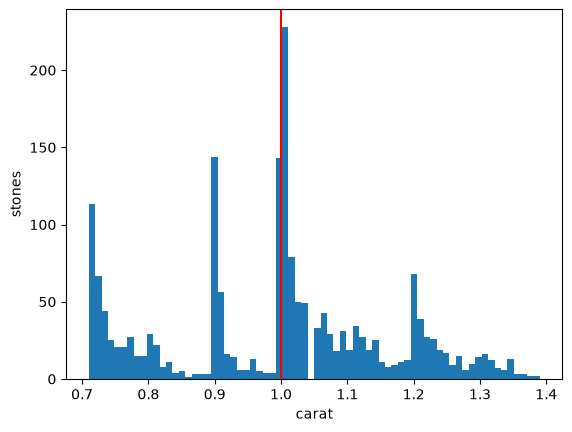

In [12]:
plt.hist(gems.carat[(gems.carat > 0.7) & (gems.carat < 1.4)], bins=70)
plt.axvline(1.0, color="red")
plt.xlabel("carat"); plt.ylabel("stones");

A pile at 1.00 and a hole just below it. Cutters grind away weight to reach the round number, because buyers shop for *a one carat diamond*.

## 12. Put the tree's hint into the regression



In [13]:
gems["over1"] = (gems.carat >= 1.0).astype(int)
jump = smf.ols("np.log(price) ~ np.log(carat) + over1 + C(cut) + C(color) + C(clarity)",
               data=gems).fit()

print("crossing one carat adds", round(100 * (np.exp(jump.params["over1"]) - 1), 1), "% to price")
print("p-value:", format(jump.pvalues["over1"], ".2g"))
print("AIC:", round(logfit.aic), "->", round(jump.aic))

crossing one carat adds 12.2 % to price
p-value: 6.6e-64
AIC: -5842 -> -6126


## 13. Write the sentence



In [14]:
weight = 100 * ((1.01 / 0.98)**jump.params["np.log(carat)"] - 1)
jump_pct = 100 * (np.exp(jump.params["over1"]) - 1)

total = 100 * ((1 + weight/100) * (1 + jump_pct/100) - 1)
print(f"0.98 to 1.01 carat: {weight:.0f}% for the weight, {jump_pct:.0f}% for the round number")
print(f"total: about {total:.0f}% more for nearly the same rock")

0.98 to 1.01 carat: 6% for the weight, 12% for the round number
total: about 18% more for nearly the same rock


The tree pointed at one carat. The regression put 12% and a p-value on it.